In [4]:
from google.colab import files
uploaded = files.upload()

Saving diabetes.csv to diabetes.csv


In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [7]:
df = pd.read_csv('diabetes.csv')

In [ ]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [11]:
print(f"Shape: {df.shape}\n")
print(f"\ndatatypes: \n{df.dtypes}")

Shape: (768, 10)


datatypes: 
Pregnancies                    int64
Glucose                        int64
BloodPressure                  int64
SkinThickness                  int64
Insulin                        int64
BMI                          float64
DiabetesPedigreeFunction     float64
Age                            int64
Outcome                        int64
AgeGroup                    category
dtype: object


In [12]:
total_missing = df.isnull().sum().sum()
print("Total missing values in the DataFrame:", total_missing)

Total missing values in the DataFrame: 1


Conclusions drawn :

1.The dataset does not contain any null values .

2.The dataset has only 9 columns and all of them seem relevant

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   Pregnancies               768 non-null    int64   
 1   Glucose                   768 non-null    int64   
 2   BloodPressure             768 non-null    int64   
 3   SkinThickness             768 non-null    int64   
 4   Insulin                   768 non-null    int64   
 5   BMI                       768 non-null    float64 
 6   DiabetesPedigreeFunction  768 non-null    float64 
 7   Age                       768 non-null    int64   
 8   Outcome                   768 non-null    int64   
 9   AgeGroup                  767 non-null    category
dtypes: category(1), float64(2), int64(7)
memory usage: 55.1 KB


In [14]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


Outcome
0    65.104167
1    34.895833
Name: count, dtype: float64
Patients with Diabetes: 268
Patients without Diabetes: 500


<Axes: title={'center': 'Barplot showing number of diabetic and non-diabetic participants'}, xlabel='Outcome', ylabel='count'>

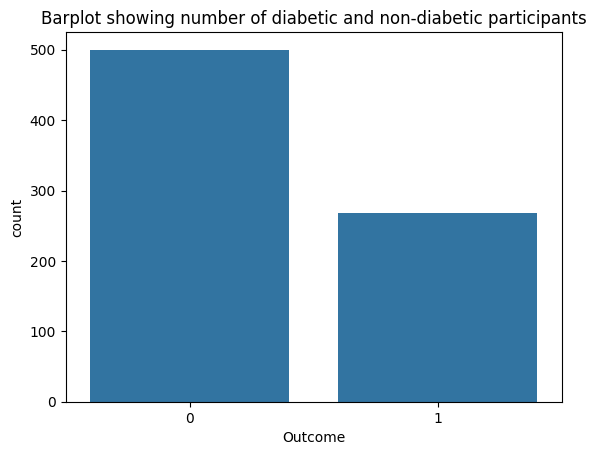

In [15]:
df["Outcome"].value_counts()

print(100 * df["Outcome"].value_counts() / len(df))

with_diabetes = df['Outcome'].value_counts()[1]
without_diabetes = df['Outcome'].value_counts()[0]
print(f"Patients with Diabetes: {with_diabetes}\nPatients without Diabetes: {without_diabetes}")
plt.title('Barplot showing number of diabetic and non-diabetic participants' )

sns.countplot(x="Outcome", data=df)

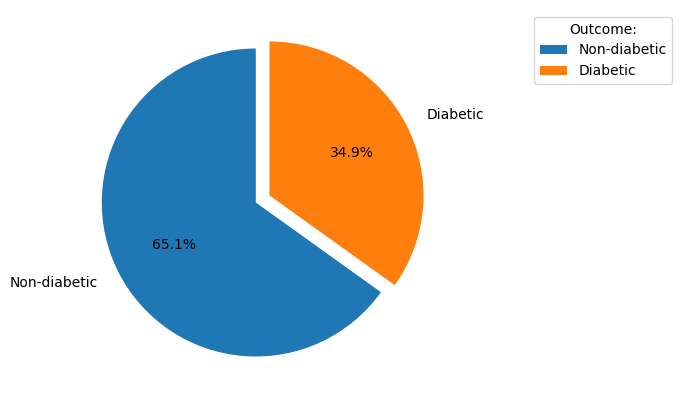

In [16]:
plt.figure(figsize=(5,5))

plt.pie(df['Outcome'].value_counts(),labels=['Non-diabetic','Diabetic'],radius=1,
        autopct='%1.1f%%',explode = [0,0.1],labeldistance=1.15,startangle = 90)

plt.legend(title = 'Outcome:',loc='upper right', bbox_to_anchor=(1.6,1))
plt.show()

In [17]:
bmi_bins = [0, 18.5, 24.9, 29.9, 39.9, float('inf')]
bmi_labels = ['Underweight', 'Healthy Range', 'Overweight', 'Obesity', 'Severe Obesity']

# Create a new column 'BMICategory' in your DataFrame
df['BMICategory'] = pd.cut(df['BMI'], bins=bmi_bins, labels=bmi_labels, right=False)

# Display the first few rows of the DataFrame with the new 'BMICategory' column
print(df[['BMI', 'BMICategory']].head())

    BMI     BMICategory
0  33.6         Obesity
1  26.6      Overweight
2  23.3   Healthy Range
3  28.1      Overweight
4  43.1  Severe Obesity


/tmp/ipykernel_580/3806087841.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='BMICategory', y='BloodPressure', data=df, estimator='mean', ci=None, linewidth=0)


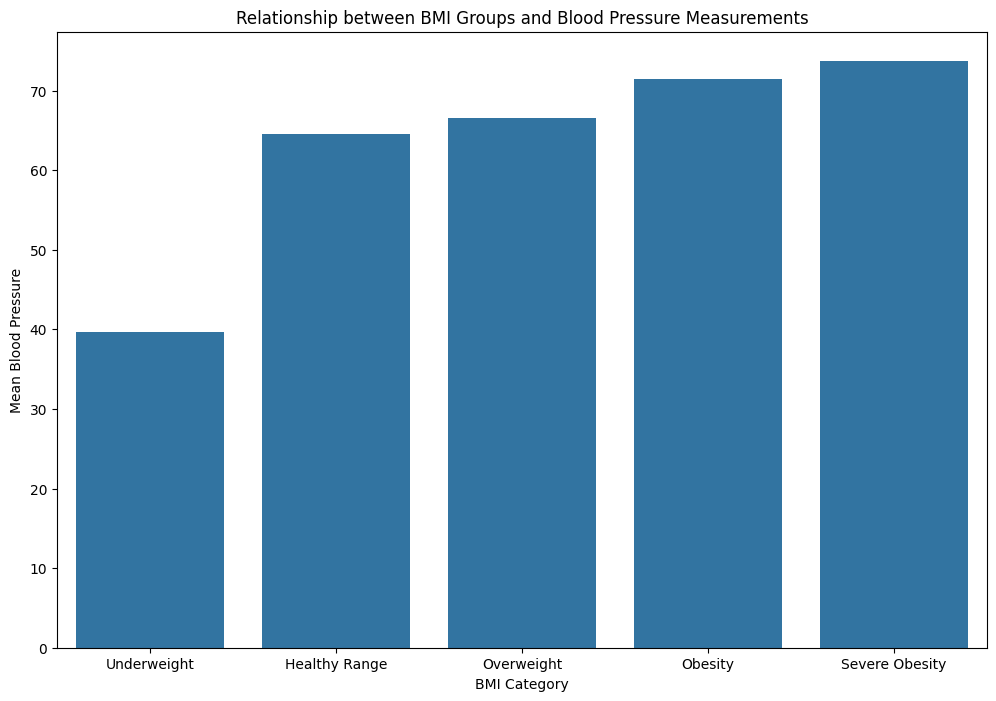

In [18]:
plt.figure(figsize=(12, 8))
sns.barplot(x='BMICategory', y='BloodPressure', data=df, estimator='mean', ci=None, linewidth=0)
plt.title('Relationship between BMI Groups and Blood Pressure Measurements')
plt.xlabel('BMI Category')
plt.ylabel('Mean Blood Pressure')
plt.show()

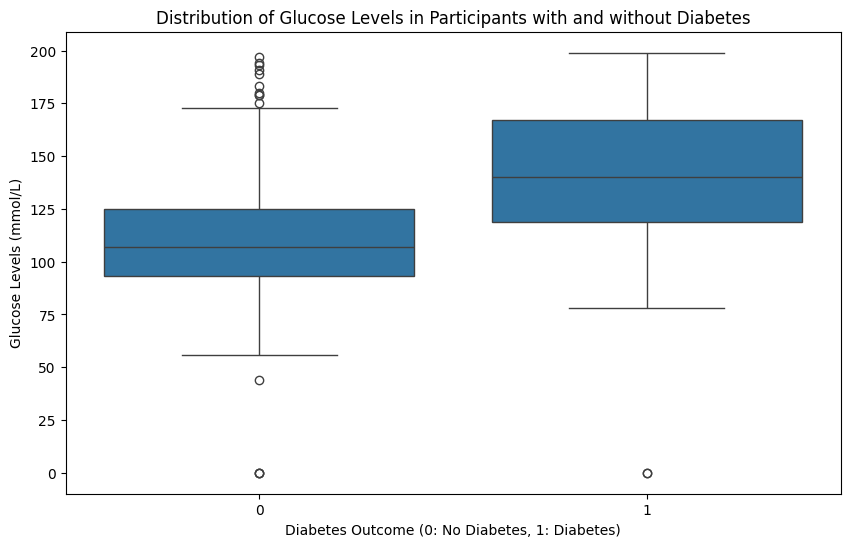

In [19]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Outcome', y='Glucose', data=df)
plt.title('Distribution of Glucose Levels in Participants with and without Diabetes')
plt.xlabel('Diabetes Outcome (0: No Diabetes, 1: Diabetes)')
plt.ylabel('Glucose Levels (mmol/L)')
plt.show()

In [20]:
mean_age = df['Age'].mean()
median_age = df['Age'].median()
std_age = df['Age'].std()

print(f"Mean Age: {mean_age}")
print(f"Median Age: {median_age}")
print(f"Standard Deviation of Age: {std_age}")

Mean Age: 33.240885416666664
Median Age: 29.0
Standard Deviation of Age: 11.76023154067868


In [21]:
age_groups = df.groupby('Age')['Outcome'].mean()

/tmp/ipykernel_580/2615690480.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  diabetes_female_df['AgeGroup'] = pd.cut(diabetes_female_df['Age'], bins=age_bins, labels=age_labels, right=False)
/tmp/ipykernel_580/2615690480.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='AgeGroup', data=diabetes_female_df, palette='viridis')


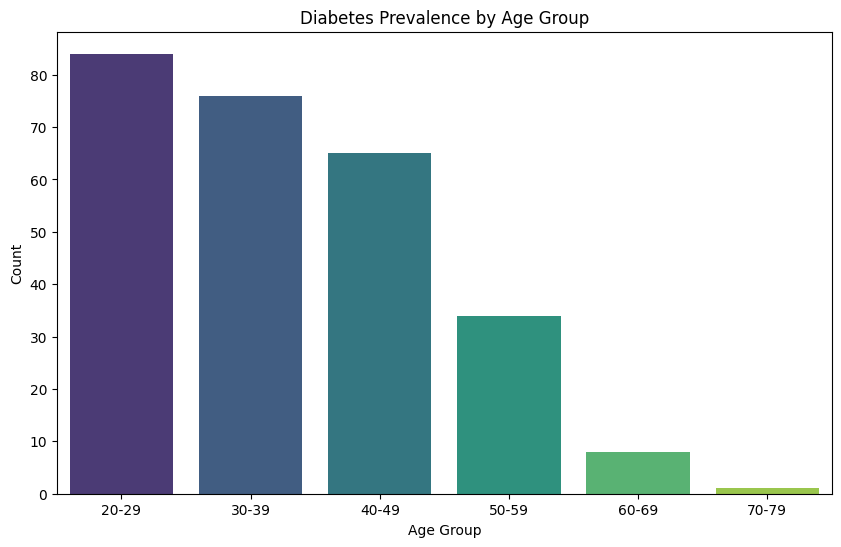

In [22]:
diabetes_female_df = df[(df['Outcome'] == 1)]

# Define age groups
age_bins = [20, 30, 40, 50, 60, 70, 80]
age_labels = ['20-29', '30-39', '40-49', '50-59', '60-69', '70-79']

# Create a new 'AgeGroup' column
diabetes_female_df['AgeGroup'] = pd.cut(diabetes_female_df['Age'], bins=age_bins, labels=age_labels, right=False)

# Plotting the bar graph
plt.figure(figsize=(10, 6))
sns.countplot(x='AgeGroup', data=diabetes_female_df, palette='viridis')

# Customizing the plot
plt.title('Diabetes Prevalence by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.show()






/tmp/ipykernel_580/4237362475.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Age', y='Outcome', data=df, estimator='mean', ci=None)


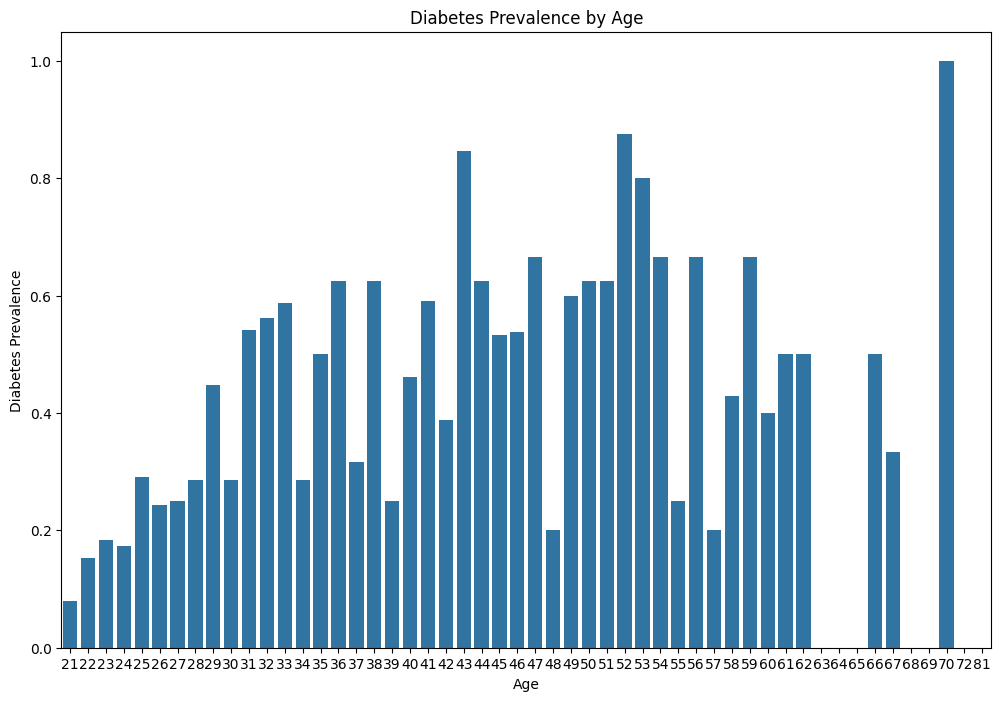

In [23]:
plt.figure(figsize=(12, 8))
sns.barplot(x='Age', y='Outcome', data=df, estimator='mean', ci=None)
plt.title('Diabetes Prevalence by Age')
plt.xlabel('Age')
plt.ylabel('Diabetes Prevalence')
plt.show()

/tmp/ipykernel_580/2212281210.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='AgeGroup', data=df, palette='viridis')


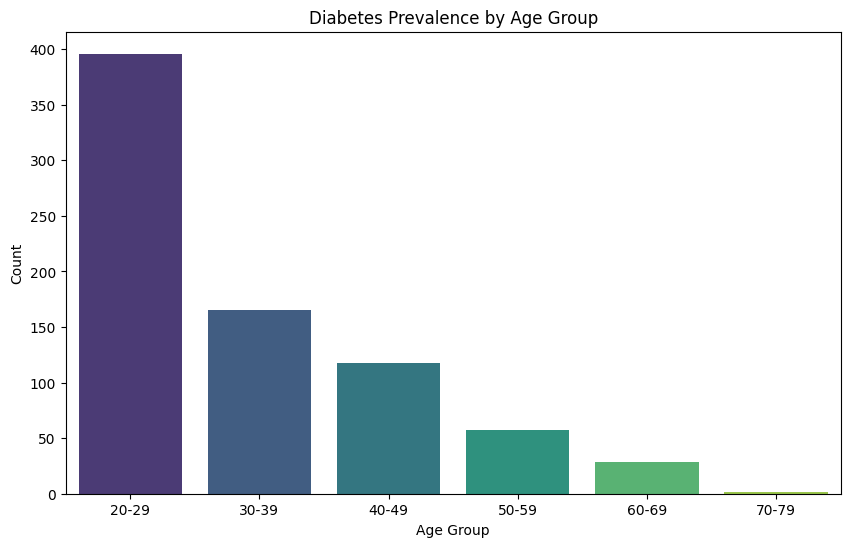

In [24]:

# Define age groups
age_bins = [20, 30, 40, 50, 60, 70, 80]
age_labels = ['20-29', '30-39', '40-49', '50-59', '60-69', '70-79']

# Create a new 'AgeGroup' column
df['AgeGroup'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels, right=False)

# Plotting the bar graph
plt.figure(figsize=(10, 6))
sns.countplot(x='AgeGroup', data=df, palette='viridis')

# Customizing the plot
plt.title('Diabetes Prevalence by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.show()

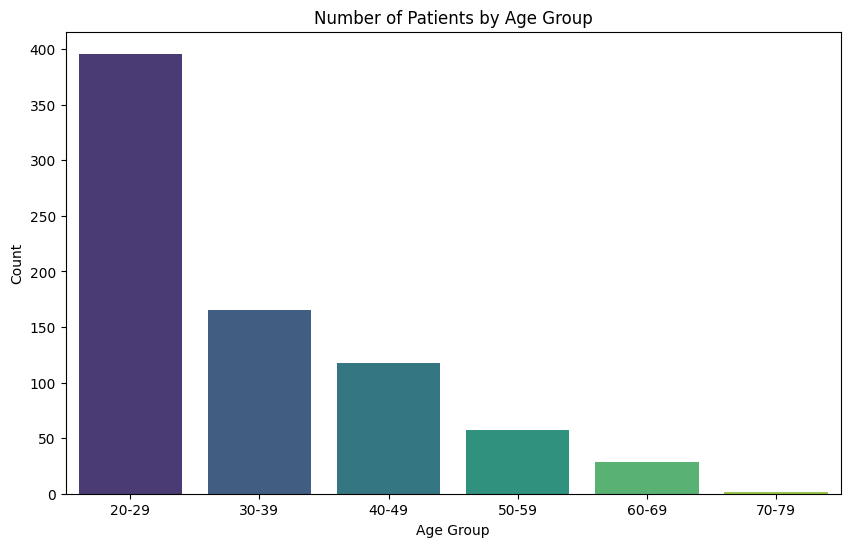

In [26]:
age_bins = [20, 30, 40, 50, 60, 70, 80]
age_labels = ['20-29', '30-39', '40-49', '50-59', '60-69', '70-79']
df['AgeGroup'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels, right=False)

plt.figure(figsize=(10, 6))
sns.countplot(x='AgeGroup', hue='AgeGroup', palette='viridis', legend=False, data=df)
plt.title('Number of Patients by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.show()

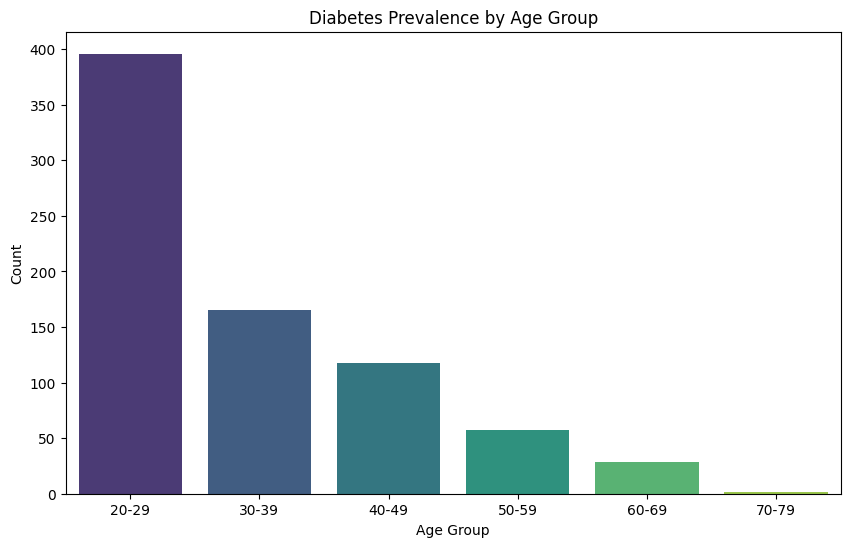

In [ ]:

age_bins = [20, 30, 40, 50, 60, 70, 80]
age_labels = ['20-29', '30-39', '40-49', '50-59', '60-69', '70-79']

df['AgeGroup'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels, right=False)

plt.figure(figsize=(10, 6))
sns.countplot(x='AgeGroup', data=df, palette='viridis')

plt.title('Diabetes Prevalence by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.show()

In [ ]:
df.corr()


<ipython-input-17-2f6f6606aa2c>:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  df.corr()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898
Glucose,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
BloodPressure,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068
SkinThickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752
Insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548
BMI,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
DiabetesPedigreeFunction,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
Age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356
Outcome,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


Therefore, for each variable, the correlation is as follows:

Pregnancies (+0.22): Positive correlation. Higher number of pregnancies slightly increases diabetes likelihood.

Glucose (+0.47): Positive correlation. Higher glucose levels significantly indicate higher diabetes risk.

BloodPressure (+0.07): Positive correlation. Slight increase in blood pressure, slight increase in diabetes risk.

SkinThickness (+0.07): Positive correlation. Slight increase in skin thickness, slight increase in diabetes risk.

Insulin (+0.13): Positive correlation. Slight increase in insulin levels, slight increase in diabetes risk.

BMI (+0.29): Positive correlation. Higher BMI indicates higher diabetes likelihood.

DiabetesPedigreeFunction (+0.17): Positive correlation. Slight increase in diabetes pedigree function, slight increase in diabetes risk.

Age (+0.24): Positive correlation. Older age is associated with higher diabetes risk.

<ipython-input-18-163b20a42f96>:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)


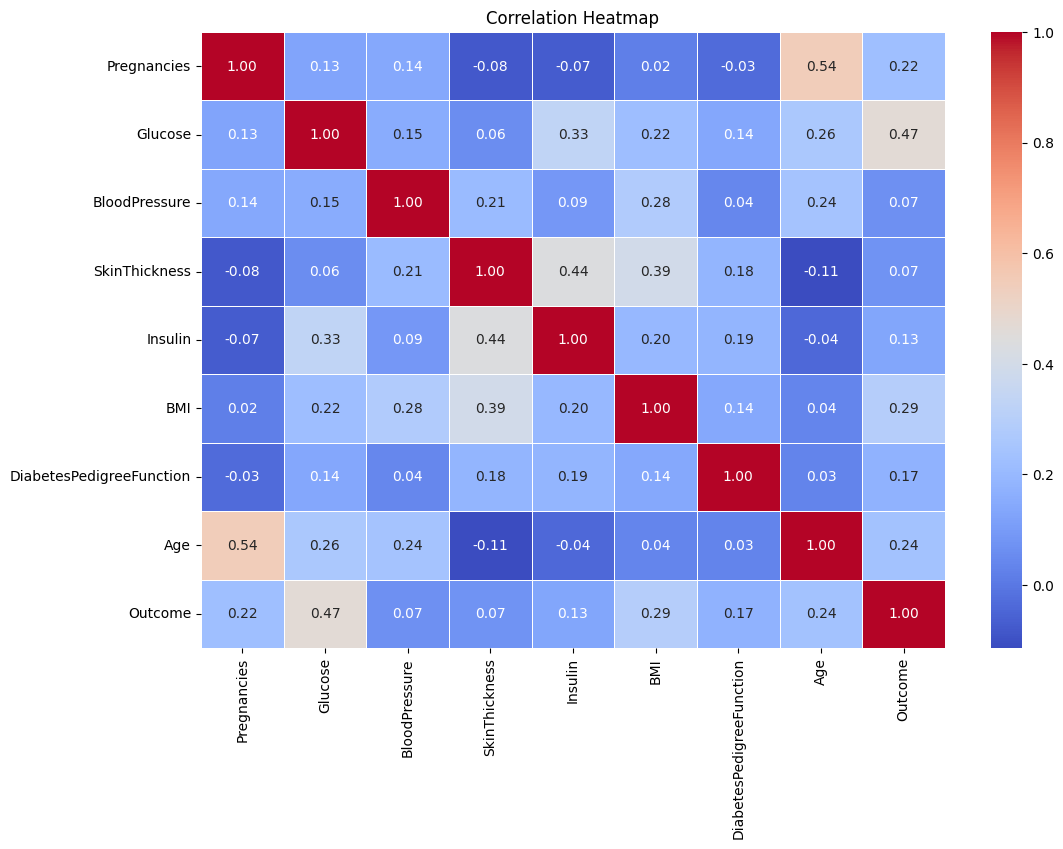

In [ ]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()